In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
df = pd.read_csv('../Dataset/bank.csv',sep=";")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.marital.unique()

<StringArray>
['married', 'single', 'divorced', 'unknown']
Length: 4, dtype: str

In [6]:
df.apply(pd.unique)

age               [56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5...
job               [housemaid, services, admin., blue-collar, tec...
marital                        [married, single, divorced, unknown]
education         [basic.4y, high.school, basic.6y, basic.9y, pr...
default                                          [no, unknown, yes]
housing                                          [no, yes, unknown]
loan                                             [no, yes, unknown]
contact                                       [telephone, cellular]
month             [may, jun, jul, aug, oct, nov, dec, mar, apr, ...
day_of_week                               [mon, tue, wed, thu, fri]
duration          [261, 149, 226, 151, 307, 198, 139, 217, 380, ...
campaign          [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 19...
pdays             [999, 6, 4, 3, 5, 1, 0, 10, 7, 8, 9, 11, 2, 12...
previous                                   [0, 1, 2, 3, 4, 5, 6, 7]
poutcome                            [nonexistent

In [7]:
df['y'] = df['y'].map({
    'no': 0,
    'yes':1
})

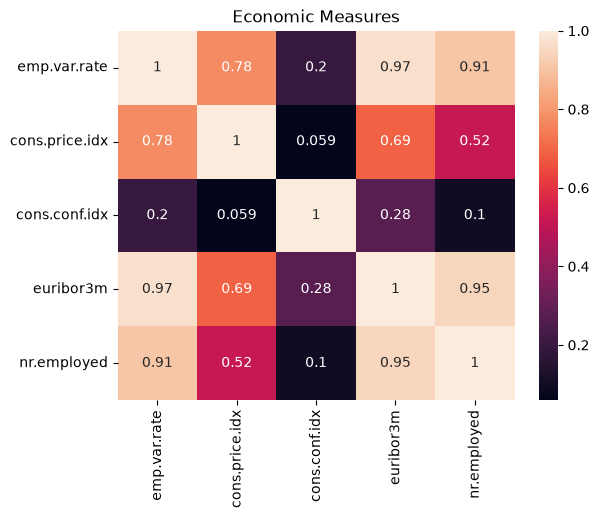

In [8]:
corr  = df[
    ['emp.var.rate',
     'cons.price.idx',
     'cons.conf.idx',
     'euribor3m',
     'nr.employed']
].corr()

sns.heatmap(
    data = corr,
    annot = True,
)
plt.title('Economic Measures')
plt.show()

In [9]:
df['nr.employed'].min()

np.float64(4963.6)

In [10]:
df['marital'].unique()

<StringArray>
['married', 'single', 'divorced', 'unknown']
Length: 4, dtype: str

In [11]:
df['marital'] = df['marital'].map({
    'married' : 1,
    'single' : 0, 
    'divorced' : 2
})

In [12]:
df['marital'].isna().sum()

np.int64(80)

In [13]:
df = df.dropna(subset=['marital'], axis=0)

In [14]:
df['marital']

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
41183    1.0
41184    1.0
41185    1.0
41186    1.0
41187    1.0
Name: marital, Length: 41108, dtype: float64

In [15]:
df[['default','housing','loan']].isna().sum()

default    0
housing    0
loan       0
dtype: int64

In [16]:
df['default'] = df['default'].map({
    'no':0,
    'yes':1,
    'unknown':np.nan
})

In [17]:
df['housing'] = df['housing'].map({
    'no' : 0,
    'yes' : 1,
    'unknown' : np.nan
})

In [18]:
df['loan'] = df['loan'].map({
    'no' : 0,
    'yes' : 1,
    'unknown' : np.nan
})

In [19]:
df[['default','housing','loan']].isna().sum()

default    8586
housing     989
loan        989
dtype: int64

In [20]:
df['default'].isna().sum()

np.int64(8586)

In [21]:
df = df.dropna(subset = ['housing','loan'])

In [22]:
df.isna().sum()

age                  0
job                  0
marital              0
education            0
default           8359
housing              0
loan                 0
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 40119 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             40119 non-null  int64  
 1   job             40119 non-null  str    
 2   marital         40119 non-null  float64
 3   education       40119 non-null  str    
 4   default         31760 non-null  float64
 5   housing         40119 non-null  float64
 6   loan            40119 non-null  float64
 7   contact         40119 non-null  str    
 8   month           40119 non-null  str    
 9   day_of_week     40119 non-null  str    
 10  duration        40119 non-null  int64  
 11  campaign        40119 non-null  int64  
 12  pdays           40119 non-null  int64  
 13  previous        40119 non-null  int64  
 14  poutcome        40119 non-null  str    
 15  emp.var.rate    40119 non-null  float64
 16  cons.price.idx  40119 non-null  float64
 17  cons.conf.idx   40119 non-null  float64
 18  eu

In [24]:
df.poutcome.unique()

<StringArray>
['nonexistent', 'failure', 'success']
Length: 3, dtype: str

In [25]:
df['poutcome'] = df['poutcome'].map({
    'failure' : 0,
    'success' : 1,
    'nonexistent' : np.nan
})

In [26]:
df['poutcome'].isna().sum()

np.int64(34651)

In [27]:
df['poutcome'] = df['poutcome'].fillna(2)

In [28]:
df['contact'].unique()

<StringArray>
['telephone', 'cellular']
Length: 2, dtype: str

In [29]:
df['contact'] = df['contact'].map({
    'telephone' : 0,
    'cellular' : 1
})

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 40119 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             40119 non-null  int64  
 1   job             40119 non-null  str    
 2   marital         40119 non-null  float64
 3   education       40119 non-null  str    
 4   default         31760 non-null  float64
 5   housing         40119 non-null  float64
 6   loan            40119 non-null  float64
 7   contact         40119 non-null  int64  
 8   month           40119 non-null  str    
 9   day_of_week     40119 non-null  str    
 10  duration        40119 non-null  int64  
 11  campaign        40119 non-null  int64  
 12  pdays           40119 non-null  int64  
 13  previous        40119 non-null  int64  
 14  poutcome        40119 non-null  float64
 15  emp.var.rate    40119 non-null  float64
 16  cons.price.idx  40119 non-null  float64
 17  cons.conf.idx   40119 non-null  float64
 18  eu

In [31]:
temp = df[df['default'].isna()]

In [32]:
temp.info()

<class 'pandas.DataFrame'>
Index: 8359 entries, 1 to 40986
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             8359 non-null   int64  
 1   job             8359 non-null   str    
 2   marital         8359 non-null   float64
 3   education       8359 non-null   str    
 4   default         0 non-null      float64
 5   housing         8359 non-null   float64
 6   loan            8359 non-null   float64
 7   contact         8359 non-null   int64  
 8   month           8359 non-null   str    
 9   day_of_week     8359 non-null   str    
 10  duration        8359 non-null   int64  
 11  campaign        8359 non-null   int64  
 12  pdays           8359 non-null   int64  
 13  previous        8359 non-null   int64  
 14  poutcome        8359 non-null   float64
 15  emp.var.rate    8359 non-null   float64
 16  cons.price.idx  8359 non-null   float64
 17  cons.conf.idx   8359 non-null   float64
 18  eur

In [33]:
test = df[(~df['default'].isna())]

In [34]:
test.info()

<class 'pandas.DataFrame'>
Index: 31760 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             31760 non-null  int64  
 1   job             31760 non-null  str    
 2   marital         31760 non-null  float64
 3   education       31760 non-null  str    
 4   default         31760 non-null  float64
 5   housing         31760 non-null  float64
 6   loan            31760 non-null  float64
 7   contact         31760 non-null  int64  
 8   month           31760 non-null  str    
 9   day_of_week     31760 non-null  str    
 10  duration        31760 non-null  int64  
 11  campaign        31760 non-null  int64  
 12  pdays           31760 non-null  int64  
 13  previous        31760 non-null  int64  
 14  poutcome        31760 non-null  float64
 15  emp.var.rate    31760 non-null  float64
 16  cons.price.idx  31760 non-null  float64
 17  cons.conf.idx   31760 non-null  float64
 18  eu

In [35]:
corr = test.corr(numeric_only = True)

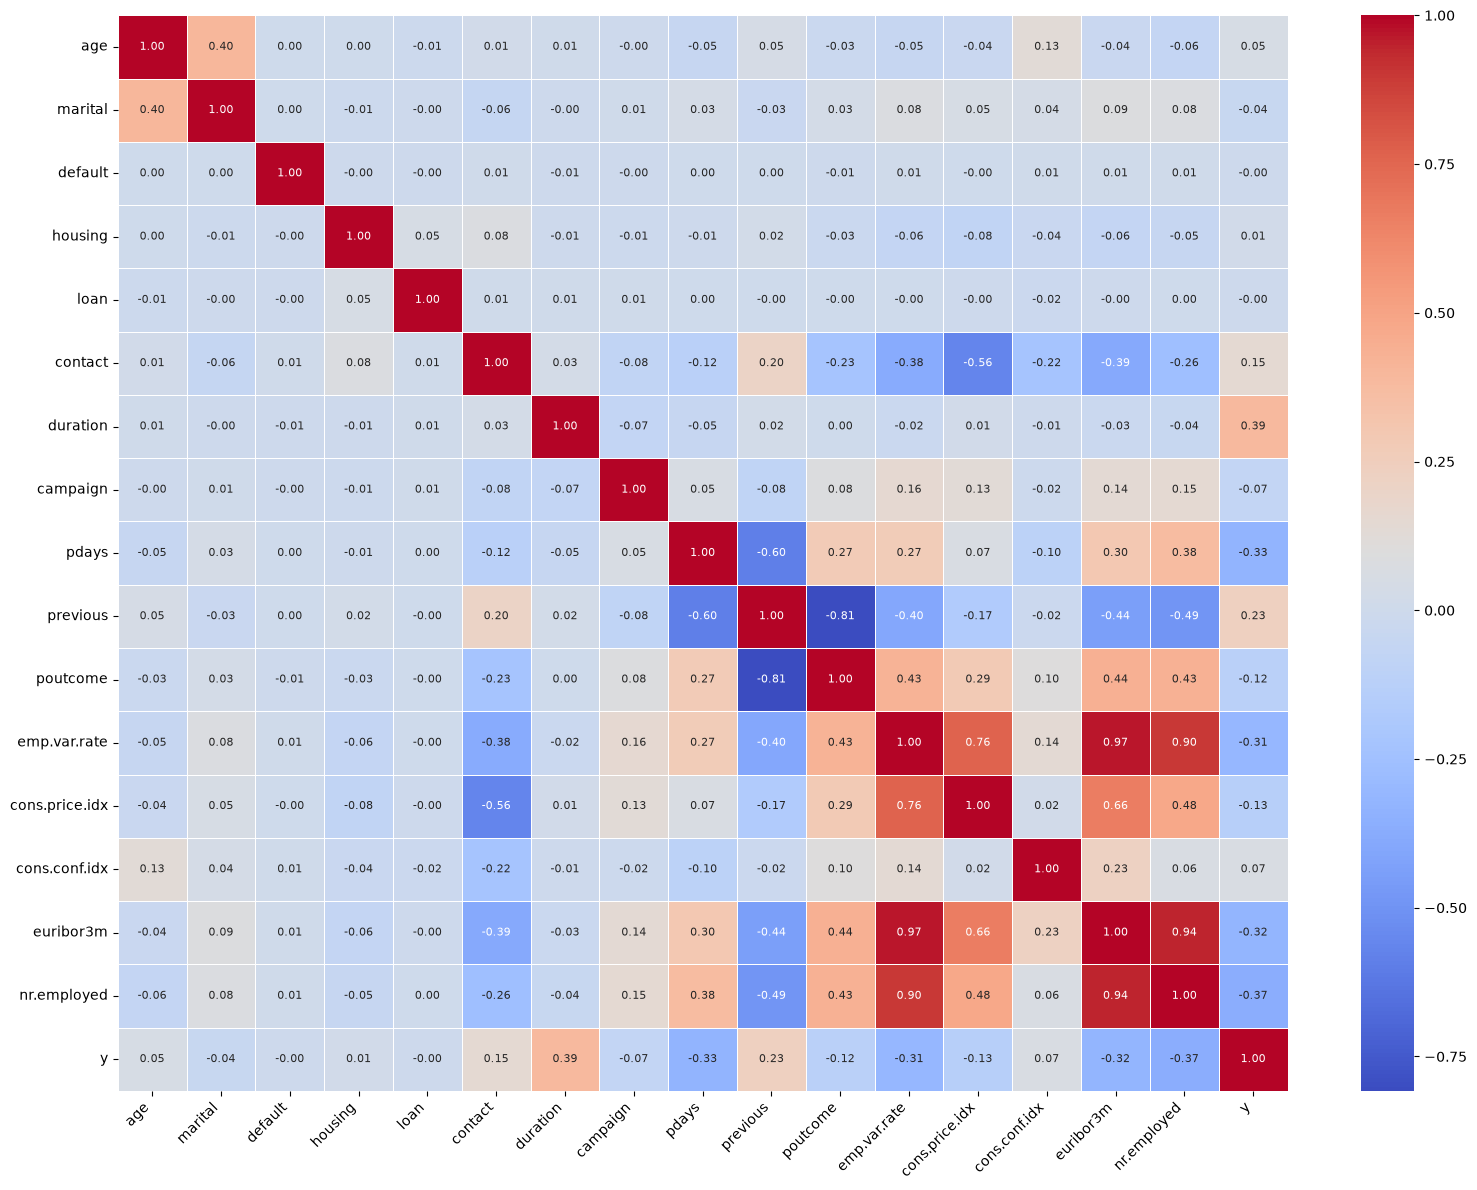

In [36]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
x = test.drop('default',axis = 1)
x = x[['age', 'marital', 'housing', 'loan', 'contact',
        'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y']]

y = test['default']

In [38]:
x.info()

<class 'pandas.DataFrame'>
Index: 31760 entries, 0 to 41187
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             31760 non-null  int64  
 1   marital         31760 non-null  float64
 2   housing         31760 non-null  float64
 3   loan            31760 non-null  float64
 4   contact         31760 non-null  int64  
 5   duration        31760 non-null  int64  
 6   campaign        31760 non-null  int64  
 7   pdays           31760 non-null  int64  
 8   previous        31760 non-null  int64  
 9   poutcome        31760 non-null  float64
 10  emp.var.rate    31760 non-null  float64
 11  cons.price.idx  31760 non-null  float64
 12  cons.conf.idx   31760 non-null  float64
 13  euribor3m       31760 non-null  float64
 14  nr.employed     31760 non-null  float64
 15  y               31760 non-null  int64  
dtypes: float64(9), int64(7)
memory usage: 4.1 MB


In [59]:
model = DecisionTreeClassifier(
    max_depth = 3,
    random_state = 43
)

In [60]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 43)

In [61]:
model.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",43
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

In [62]:
y_pred = model.predict(x_test)

In [44]:
tp,tn,fp,fn = 0,0,0,0
test = zip(y_test,y_pred)


In [67]:
for actual, predict in test:
    if actual == 0 :
        if predict == 0:
            tn += 1
        elif predict == 1:
            fp += 1
    elif actual == 1:
        if predict == 0:
            fn += 1
        elif predict == 1:
            tp += 1

print("True Positive : ",tp) 
print("True Negative : ",tn)
print("False Positive : ",fp)
print("False Negative : ",fn)
# conf = confusion_matrix(y_test,y_pred)

True Positive :  0
True Negative :  6343
False Positive :  0
False Negative :  2


In [70]:
y.value_counts()

default
0.0    31757
1.0        3
Name: count, dtype: int64

In [63]:
np.unique(y_pred)

array([0.])

In [71]:
y_temp =model.predict_proba(x_test)[:, 1]

In [ ]:
y_pred_num = y_pred.

In [55]:
y_test.unique()

array([0., 1.])

In [64]:
conf = confusion_matrix(y_test,y_pred)

In [66]:
conf

array([[6350,    0],
       [   2,    0]])

Assume that the value of the Remaining Null values under default as 1

In [73]:
df.info()

<class 'pandas.DataFrame'>
Index: 40119 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             40119 non-null  int64  
 1   job             40119 non-null  str    
 2   marital         40119 non-null  float64
 3   education       40119 non-null  str    
 4   default         31760 non-null  float64
 5   housing         40119 non-null  float64
 6   loan            40119 non-null  float64
 7   contact         40119 non-null  int64  
 8   month           40119 non-null  str    
 9   day_of_week     40119 non-null  str    
 10  duration        40119 non-null  int64  
 11  campaign        40119 non-null  int64  
 12  pdays           40119 non-null  int64  
 13  previous        40119 non-null  int64  
 14  poutcome        40119 non-null  float64
 15  emp.var.rate    40119 non-null  float64
 16  cons.price.idx  40119 non-null  float64
 17  cons.conf.idx   40119 non-null  float64
 18  eu

In [75]:
df['default'] = df['default'].fillna(1)

In [76]:
df.info()

<class 'pandas.DataFrame'>
Index: 40119 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             40119 non-null  int64  
 1   job             40119 non-null  str    
 2   marital         40119 non-null  float64
 3   education       40119 non-null  str    
 4   default         40119 non-null  float64
 5   housing         40119 non-null  float64
 6   loan            40119 non-null  float64
 7   contact         40119 non-null  int64  
 8   month           40119 non-null  str    
 9   day_of_week     40119 non-null  str    
 10  duration        40119 non-null  int64  
 11  campaign        40119 non-null  int64  
 12  pdays           40119 non-null  int64  
 13  previous        40119 non-null  int64  
 14  poutcome        40119 non-null  float64
 15  emp.var.rate    40119 non-null  float64
 16  cons.price.idx  40119 non-null  float64
 17  cons.conf.idx   40119 non-null  float64
 18  eu

## Feature Selection

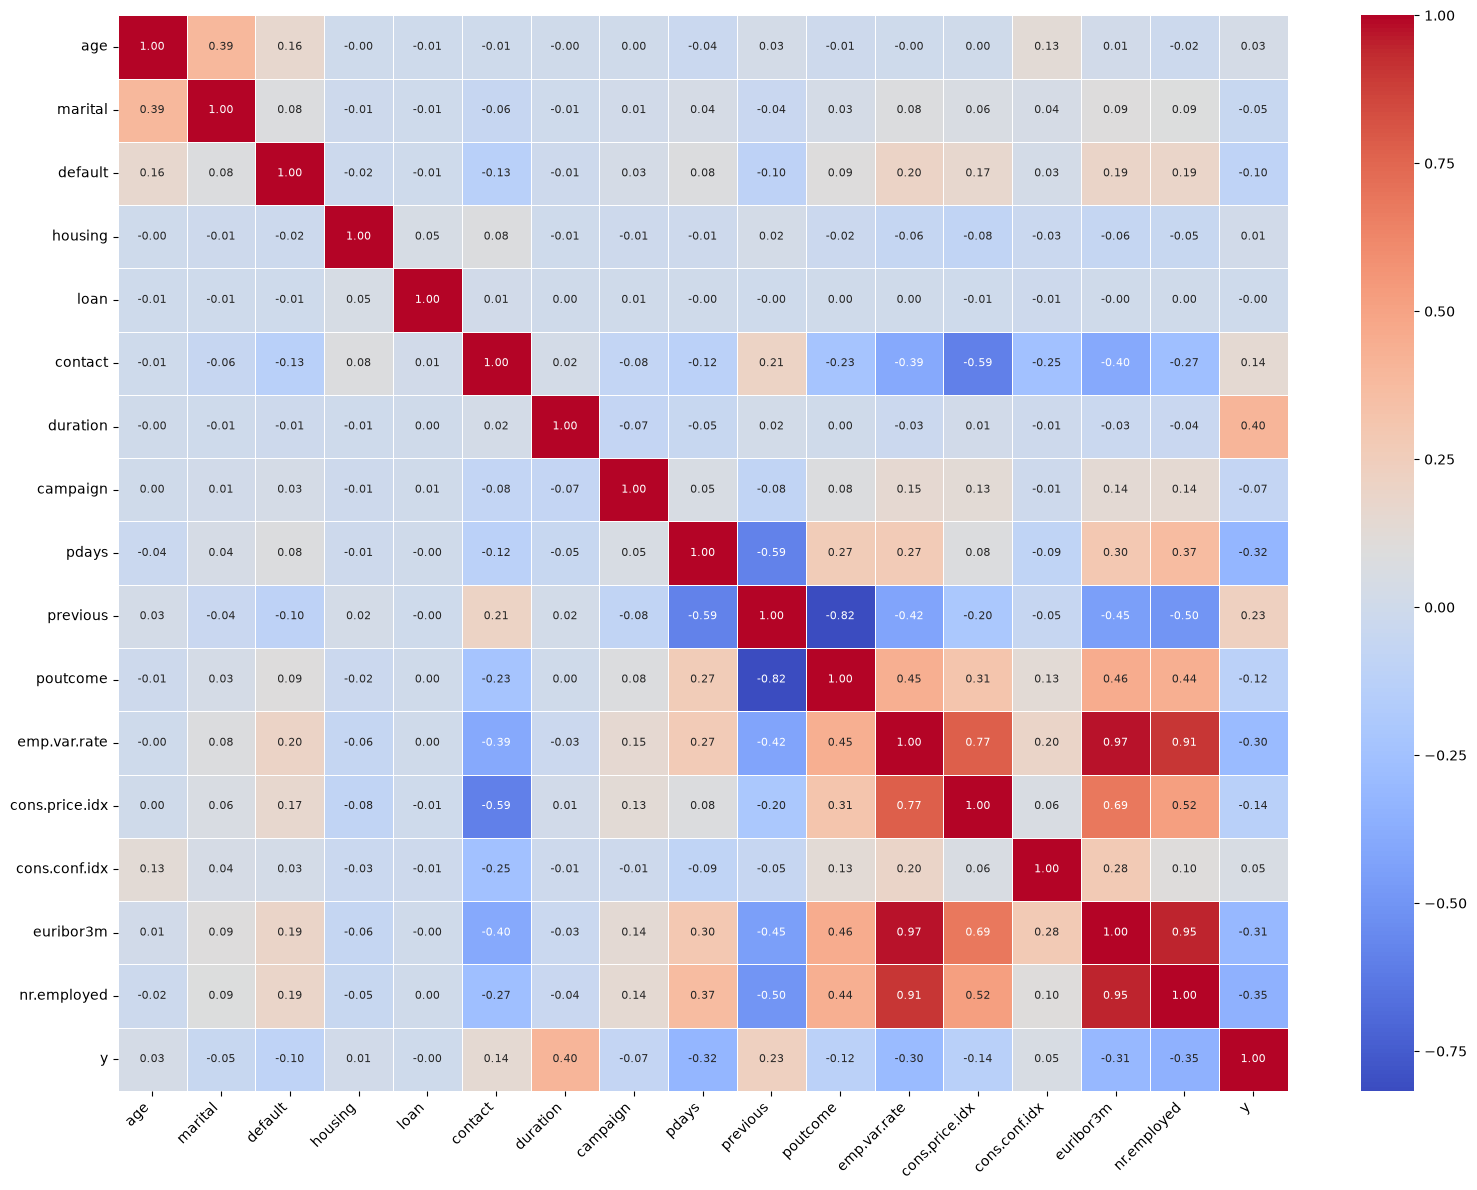

In [79]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [90]:
x = df[['duration','previous','nr.employed','euribor3m','emp.var.rate','pdays']]
y = df['y']

regressor = DecisionTreeRegressor(
    max_depth = 5,
    random_state = 43,
)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2)
regressor.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",43
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``

In [91]:
y_pred = regressor.predict(x_test)

mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error : ",mse)
print("mean Absolute Error : ",mae)
print("R2 Score : ",r2)
print("RMSE : ",rmse)

Mean Squared Error :  0.060223067448816114
mean Absolute Error :  0.11865883854394994
R2 Score :  0.4182480506135574
RMSE :  0.2454038863767567
